In [1]:
import pandas as pd


In [3]:
import zipfile

with zipfile.ZipFile("ipl_json.zip", "r") as z:
    z.extractall("ipl_data")   # All JSONs go into a folder called ipl_data

print("Done! Files extracted.")

Done! Files extracted.


In [8]:
import json
import os
import pandas as pd

match_records = []      # One row per match
delivery_records = []   # One row per ball bowled

json_folder = "ipl_data"

for filename in os.listdir(json_folder):
    if not filename.endswith(".json"):
        continue

    filepath = os.path.join(json_folder, filename)
    match_id = filename.replace(".json", "")

    with open(filepath, "r") as f:
        data = json.load(f)

    info = data["info"]

    # ── Match-level row ──────────────────────────────────────
    match_records.append({
        "match_id":    match_id,
        "date":        info.get("dates", [None])[0],
        "season":      info.get("season"),
        "venue":       info.get("venue"),
        "city":        info.get("city"),
        "team1":       info["teams"][0],
        "team2":       info["teams"][1],
        "toss_winner": info["toss"]["winner"],
        "toss_decision": info["toss"]["decision"],
        "winner":      info.get("outcome", {}).get("winner"),
        "win_by_runs": info.get("outcome", {}).get("by", {}).get("runs"),
        "win_by_wickets": info.get("outcome", {}).get("by", {}).get("wickets"),
    })

    # ── Ball-by-ball rows ────────────────────────────────────
    for inning in data.get("innings", []):
        team_batting = inning.get("team")
        for over_data in inning.get("overs", []):
            over_num = over_data["over"]
            for ball_idx, delivery in enumerate(over_data["deliveries"]):
                runs = delivery.get("runs", {})
                wicket_info = delivery.get("wickets", [{}])[0] if delivery.get("wickets") else {}
                delivery_records.append({
                    "match_id":    match_id,
                    "team_batting": team_batting,
                    "over":        over_num,
                    "ball":        ball_idx + 1,
                    "batter":      delivery.get("batter"),
                    "bowler":      delivery.get("bowler"),
                    "runs_batter": runs.get("batter", 0),
                    "runs_extras": runs.get("extras", 0),
                    "runs_total":  runs.get("total", 0),
                    "is_wicket":   1 if delivery.get("wickets") else 0,
                    "wicket_kind": wicket_info.get("kind"),
                })

# Convert to DataFrames
matches_df    = pd.DataFrame(match_records)
deliveries_df = pd.DataFrame(delivery_records)

print(f"✅ Matches loaded:    {len(matches_df)}")
print(f"✅ Deliveries loaded: {len(deliveries_df)}")

✅ Matches loaded:    1226
✅ Deliveries loaded: 291574


✅ Libraries ready!
👉 A file picker will appear below. Select your  ipl_json.zip  file.


Saving ipl_json.zip to ipl_json.zip
✅ Extracted 1226 JSON match files into 'ipl_data/'
✅ matches_df    → 1,226 rows  ×  13 columns
✅ deliveries_df → 291,574 rows  ×  16 columns

Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']
=== MATCHES DF ===
  match_id season       date                                      venue       city                   team1                        team2                  toss_winner toss_decision            match_winner  win_by_runs  win_by_wickets player_of_match
0  1082591   2017 2017-04-05  Rajiv Gandhi International Stadium, Uppal  Hyderabad     Sunrisers Hyderabad  Royal Challengers Bangalore  Royal Challengers Bangalore         field     Sunrisers Hyderabad         35.0             NaN    Yuvraj Singh
1  1082592   2017 2017-04-06    Maharashtra Cricket Association Stadium       Pune  Rising Pune Supergiant               Mumbai 

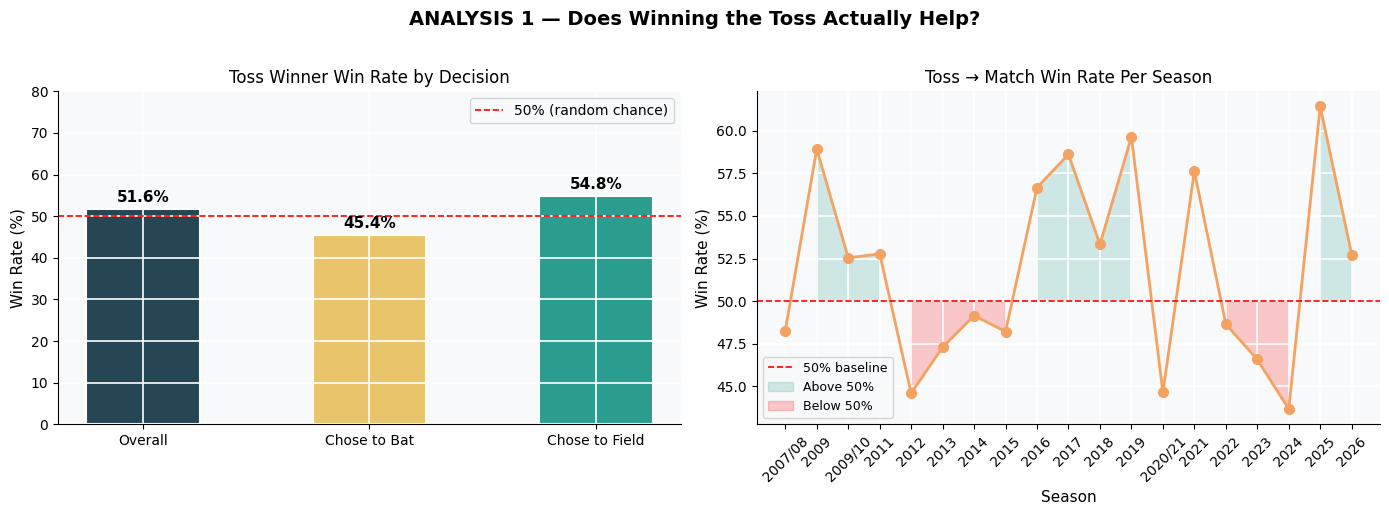


📌 KEY INSIGHT:
   Overall: Toss winners win 51.6% of matches
   When batting first : 45.4%  win rate
   When fielding first: 54.8%  win rate
   → Toss advantage is MINIMAL — barely better than a coin flip!


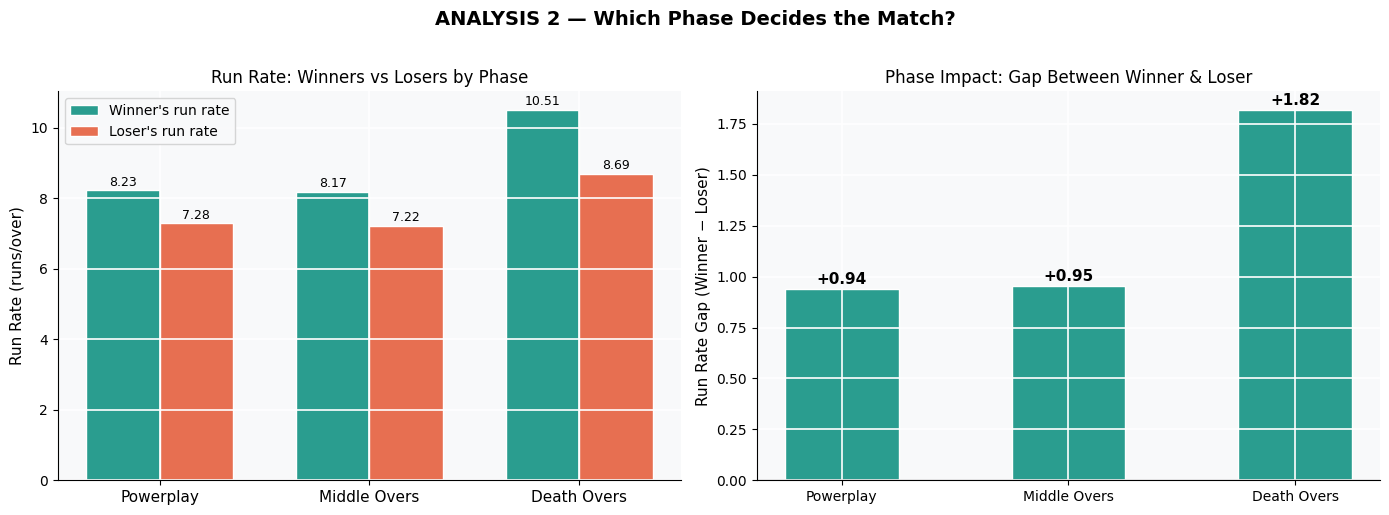


📌 KEY INSIGHT:
   Powerplay     : Winners score +0.94 runs/over more than losers
   Middle Overs  : Winners score +0.95 runs/over more than losers
   Death Overs   : Winners score +1.82 runs/over more than losers

   → The 'Death Overs' is where matches are most often won or lost!


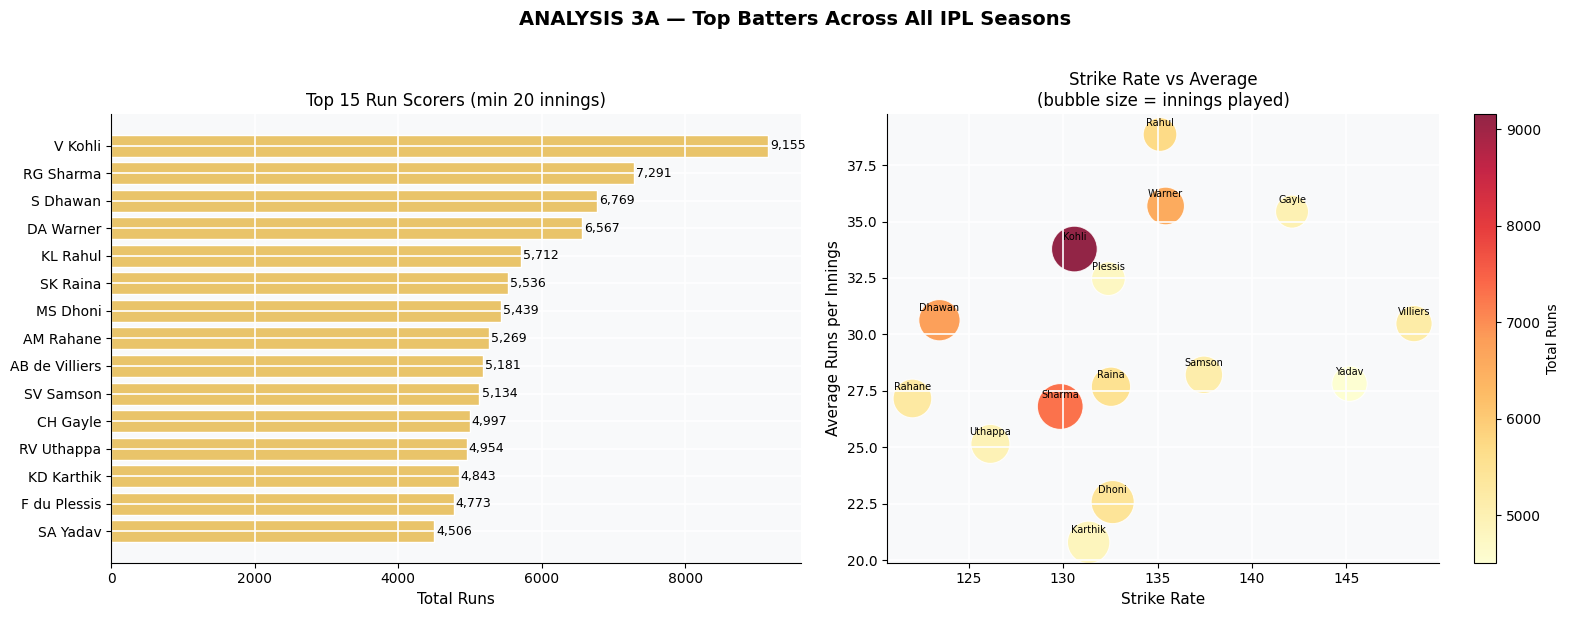


📌 TOP 10 BATTERS:
        batter  total_runs  strike_rate  avg_per_innings  sixes
       V Kohli        9155   130.599144        33.782288    310
     RG Sharma        7291   129.848620        26.805147    320
      S Dhawan        6769   123.454313        30.628959    153
     DA Warner        6567   135.429986        35.690217    236
      KL Rahul        5712   135.131299        38.857143    232
      SK Raina        5536   132.535312        27.680000    204
      MS Dhoni        5439   132.626189        22.568465    264
     AM Rahane        5269   122.024085        27.159794    136
AB de Villiers        5181   148.580442        30.476471    253
     SV Samson        5134   137.456493        28.208791    242


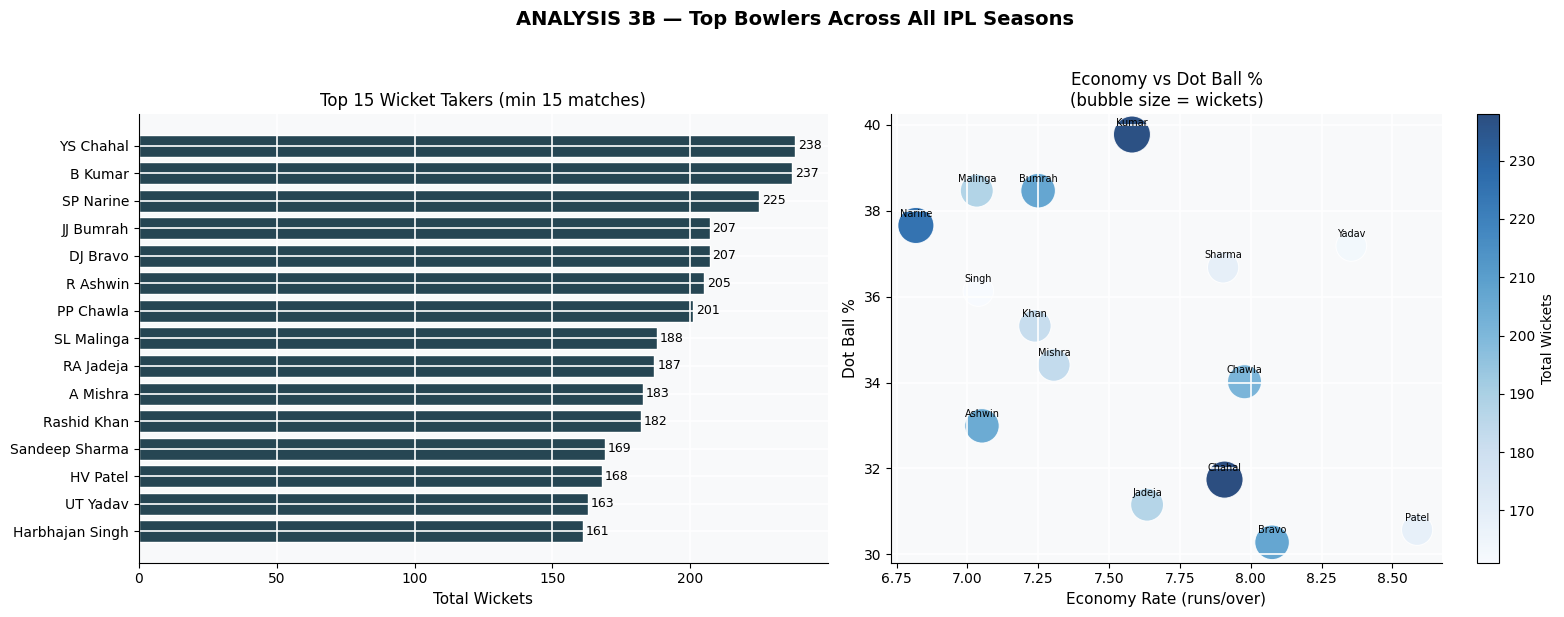


📌 TOP 10 BOWLERS:
    bowler  total_wickets  economy   dot_pct  matches
 YS Chahal            238 7.907294 31.739449      181
   B Kumar            237 7.580638 39.772971      202
 SP Narine            225 6.817948 37.655646      197
 JJ Bumrah            207 7.249399 38.465651      156
  DJ Bravo            207 8.075243 30.279126      158
  R Ashwin            205 7.051356 32.990961      217
 PP Chawla            201 7.977920 34.017972      191
SL Malinga            188 7.032952 38.466711      122
 RA Jadeja            187 7.634072 31.155193      234
  A Mishra            183 7.304878 34.407666      162


ValueError: Length mismatch: Expected axis has 13 elements, new values have 5 elements

In [1]:
# =============================================================================
#  IPL CRUNCH '26 — COMPLETE ANALYSIS NOTEBOOK
#  Run each cell in Google Colab top to bottom
#  Author: [Your Name]
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install & Import Libraries
# ─────────────────────────────────────────────────────────────────────────────
import json
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

# Chart style — makes all plots look clean and professional
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
COLORS = ["#264653","#2a9d8f","#e9c46a","#f4a261","#e76f51","#a8dadc","#457b9d"]

print("✅ Libraries ready!")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Upload & Extract ZIP
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files

print("👉 A file picker will appear below. Select your  ipl_json.zip  file.")
uploaded = files.upload()          # click to upload ipl_json.zip

ZIP_NAME   = list(uploaded.keys())[0]   # whatever you uploaded
EXTRACT_TO = "ipl_data"

with zipfile.ZipFile(ZIP_NAME, "r") as z:
    z.extractall(EXTRACT_TO)

json_files = [f for f in os.listdir(EXTRACT_TO) if f.endswith(".json")]
print(f"✅ Extracted {len(json_files)} JSON match files into '{EXTRACT_TO}/'")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Load ALL JSON Files Into Two DataFrames
# ─────────────────────────────────────────────────────────────────────────────
match_records    = []
delivery_records = []

for filename in sorted(os.listdir(EXTRACT_TO)):
    if not filename.endswith(".json"):
        continue

    match_id = filename.replace(".json", "")
    filepath = os.path.join(EXTRACT_TO, filename)

    with open(filepath, "r") as f:
        data = json.load(f)

    info    = data.get("info", {})
    outcome = info.get("outcome", {})
    toss    = info.get("toss", {})
    teams   = info.get("teams", [None, None])

    # ── One row per match ──────────────────────────────────────────────────
    match_records.append({
        "match_id":        match_id,
        "season":          str(info.get("season", "")),
        "date":            info.get("dates", [None])[0],
        "venue":           info.get("venue"),
        "city":            info.get("city"),
        "team1":           teams[0],
        "team2":           teams[1],
        "toss_winner":     toss.get("winner"),
        "toss_decision":   toss.get("decision"),   # "bat" or "field"
        "match_winner":    outcome.get("winner"),
        "win_by_runs":     outcome.get("by", {}).get("runs"),
        "win_by_wickets":  outcome.get("by", {}).get("wickets"),
        "player_of_match": info.get("player_of_match", [None])[0],
    })

    # ── One row per ball ───────────────────────────────────────────────────
    for inning_idx, inning in enumerate(data.get("innings", [])):
        team_batting = inning.get("team")
        for over_data in inning.get("overs", []):
            over_num = over_data["over"]          # 0-indexed (0 = over 1)
            for ball_idx, delivery in enumerate(over_data["deliveries"]):
                runs       = delivery.get("runs", {})
                wickets    = delivery.get("wickets", [])
                wicket_info = wickets[0] if wickets else {}

                # Phase classification
                if over_num <= 5:
                    phase = "Powerplay"
                elif over_num <= 14:
                    phase = "Middle Overs"
                else:
                    phase = "Death Overs"

                delivery_records.append({
                    "match_id":     match_id,
                    "inning":       inning_idx + 1,
                    "team_batting": team_batting,
                    "over":         over_num,
                    "ball":         ball_idx + 1,
                    "phase":        phase,
                    "batter":       delivery.get("batter"),
                    "bowler":       delivery.get("bowler"),
                    "runs_batter":  runs.get("batter", 0),
                    "runs_extras":  runs.get("extras", 0),
                    "runs_total":   runs.get("total", 0),
                    "is_wicket":    1 if wickets else 0,
                    "wicket_kind":  wicket_info.get("kind"),
                    "is_boundary":  1 if runs.get("batter") in (4, 6) else 0,
                    "is_six":       1 if runs.get("batter") == 6 else 0,
                    "is_dot":       1 if runs.get("total") == 0 else 0,
                })

# Convert to DataFrames
matches_df    = pd.DataFrame(match_records)
deliveries_df = pd.DataFrame(delivery_records)

# Parse date column
matches_df["date"] = pd.to_datetime(matches_df["date"], errors="coerce")

print(f"✅ matches_df    → {matches_df.shape[0]:,} rows  ×  {matches_df.shape[1]} columns")
print(f"✅ deliveries_df → {deliveries_df.shape[0]:,} rows  ×  {deliveries_df.shape[1]} columns")
print("\nSeasons covered:", sorted(matches_df["season"].unique()))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Quick Data Health Check
# ─────────────────────────────────────────────────────────────────────────────
print("=== MATCHES DF ===")
print(matches_df.head(3).to_string())
print()
print("=== DELIVERIES DF ===")
print(deliveries_df.head(3).to_string())
print()
print("Missing values in matches_df:")
print(matches_df.isnull().sum())


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — ANALYSIS 1: Does Winning the Toss Help?
# ─────────────────────────────────────────────────────────────────────────────
# Only keep matches that have a winner (drop rain-affected no-results)
m = matches_df.dropna(subset=["match_winner"]).copy()

m["toss_win_match_win"] = m["toss_winner"] == m["match_winner"]

overall_rate  = m["toss_win_match_win"].mean() * 100
bat_first     = m[m["toss_decision"] == "bat"]
field_first   = m[m["toss_decision"] == "field"]

bat_rate   = (bat_first["toss_winner"] == bat_first["match_winner"]).mean() * 100
field_rate = (field_first["toss_winner"] == field_first["match_winner"]).mean() * 100

# Season-wise toss win rate
season_toss = (
    m.groupby("season")["toss_win_match_win"]
     .mean()
     .mul(100)
     .reset_index()
     .rename(columns={"toss_win_match_win": "win_rate_pct"})
)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ANALYSIS 1 — Does Winning the Toss Actually Help?",
             fontsize=14, fontweight="bold", y=1.02)

# Bar: overall / bat / field
ax1 = axes[0]
categories = ["Overall", "Chose to Bat", "Chose to Field"]
values     = [overall_rate, bat_rate, field_rate]
bars = ax1.bar(categories, values, color=[COLORS[0], COLORS[2], COLORS[1]],
               width=0.5, edgecolor="white", linewidth=1.5)
ax1.axhline(50, color="red", linestyle="--", linewidth=1.2, label="50% (random chance)")
ax1.set_ylim(0, 80)
ax1.set_ylabel("Win Rate (%)", fontsize=11)
ax1.set_title("Toss Winner Win Rate by Decision", fontsize=12)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax1.legend(fontsize=10)

# Line: season-wise trend
ax2 = axes[1]
ax2.plot(season_toss["season"], season_toss["win_rate_pct"],
         marker="o", color=COLORS[3], linewidth=2, markersize=7)
ax2.axhline(50, color="red", linestyle="--", linewidth=1.2, label="50% baseline")
ax2.fill_between(season_toss["season"], 50, season_toss["win_rate_pct"],
                 where=season_toss["win_rate_pct"] > 50,
                 alpha=0.2, color=COLORS[1], label="Above 50%")
ax2.fill_between(season_toss["season"], 50, season_toss["win_rate_pct"],
                 where=season_toss["win_rate_pct"] <= 50,
                 alpha=0.2, color="red", label="Below 50%")
ax2.set_xlabel("Season", fontsize=11)
ax2.set_ylabel("Win Rate (%)", fontsize=11)
ax2.set_title("Toss → Match Win Rate Per Season", fontsize=12)
ax2.tick_params(axis="x", rotation=45)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("analysis1_toss.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📌 KEY INSIGHT:")
print(f"   Overall: Toss winners win {overall_rate:.1f}% of matches")
print(f"   When batting first : {bat_rate:.1f}%  win rate")
print(f"   When fielding first: {field_rate:.1f}%  win rate")
print(f"   → Toss advantage is {'REAL' if overall_rate > 52 else 'MINIMAL — barely better than a coin flip'}!")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — ANALYSIS 2: Which Phase Impacts Victory Most?
# ─────────────────────────────────────────────────────────────────────────────
# Join deliveries with match winner
del_m = deliveries_df.merge(
    matches_df[["match_id","match_winner"]].dropna(),
    on="match_id"
)

# Flag whether the batting team won
del_m["batting_team_won"] = (del_m["team_batting"] == del_m["match_winner"]).astype(int)

# Phase-wise run rates and wicket rates for winners vs losers
phase_stats = (
    del_m.groupby(["phase", "batting_team_won"])
         .agg(
             total_runs   = ("runs_total",  "sum"),
             total_balls  = ("runs_total",  "count"),
             total_wickets= ("is_wicket",   "sum"),
         )
         .reset_index()
)
phase_stats["run_rate"]     = phase_stats["total_runs"] / phase_stats["total_balls"] * 6
phase_stats["wicket_rate"]  = phase_stats["total_wickets"] / phase_stats["total_balls"] * 6
phase_stats["outcome_label"]= phase_stats["batting_team_won"].map({1: "Winner", 0: "Loser"})

# Phase run difference (winners vs losers)
phase_pivot = phase_stats.pivot_table(
    index="phase", columns="outcome_label", values="run_rate"
).reset_index()
phase_pivot["run_rate_gap"] = phase_pivot["Winner"] - phase_pivot["Loser"]

# Enforce phase order
phase_order = ["Powerplay", "Middle Overs", "Death Overs"]
phase_pivot = phase_pivot.set_index("phase").loc[phase_order].reset_index()

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ANALYSIS 2 — Which Phase Decides the Match?",
             fontsize=14, fontweight="bold", y=1.02)

# Grouped bars: winner vs loser run rate per phase
ax1 = axes[0]
x    = np.arange(len(phase_order))
w    = 0.35
b1   = ax1.bar(x - w/2, phase_pivot["Winner"], w, label="Winner's run rate",
               color=COLORS[1], edgecolor="white")
b2   = ax1.bar(x + w/2, phase_pivot["Loser"],  w, label="Loser's run rate",
               color=COLORS[4], edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(phase_order, fontsize=11)
ax1.set_ylabel("Run Rate (runs/over)", fontsize=11)
ax1.set_title("Run Rate: Winners vs Losers by Phase", fontsize=12)
ax1.legend(fontsize=10)
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

# Bar: run rate gap per phase
ax2 = axes[1]
colors_gap = [COLORS[1] if v > 0 else COLORS[4] for v in phase_pivot["run_rate_gap"]]
bars = ax2.bar(phase_order, phase_pivot["run_rate_gap"],
               color=colors_gap, edgecolor="white", width=0.5)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Run Rate Gap (Winner − Loser)", fontsize=11)
ax2.set_title("Phase Impact: Gap Between Winner & Loser", fontsize=12)
for bar, val in zip(bars, phase_pivot["run_rate_gap"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.05,
             f"+{val:.2f}" if val >= 0 else f"{val:.2f}",
             ha="center", va="bottom", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("analysis2_phases.png", dpi=150, bbox_inches="tight")
plt.show()

best_phase = phase_pivot.loc[phase_pivot["run_rate_gap"].idxmax(), "phase"]
print(f"\n📌 KEY INSIGHT:")
for _, row in phase_pivot.iterrows():
    print(f"   {row['phase']:<14}: Winners score {row['run_rate_gap']:+.2f} runs/over more than losers")
print(f"\n   → The '{best_phase}' is where matches are most often won or lost!")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — ANALYSIS 3A: Top Batters Across All Seasons
# ─────────────────────────────────────────────────────────────────────────────
# Only legal deliveries (no wides) for strike rate
batter_stats = (
    deliveries_df.groupby("batter")
                 .agg(
                     total_runs   = ("runs_batter", "sum"),
                     balls_faced  = ("runs_batter", "count"),
                     fours        = ("is_boundary",  "sum"),
                     sixes        = ("is_six",        "sum"),
                     innings      = ("match_id",      "nunique"),
                 )
                 .reset_index()
)
batter_stats["strike_rate"] = batter_stats["total_runs"] / batter_stats["balls_faced"] * 100
batter_stats["avg_per_innings"] = batter_stats["total_runs"] / batter_stats["innings"]

# Filter: played at least 20 innings (to avoid one-hit wonders)
top_batters = (
    batter_stats[batter_stats["innings"] >= 20]
    .sort_values("total_runs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ANALYSIS 3A — Top Batters Across All IPL Seasons",
             fontsize=14, fontweight="bold", y=1.02)

# Total runs
ax1 = axes[0]
bars = ax1.barh(top_batters["batter"][::-1],
                top_batters["total_runs"][::-1],
                color=COLORS[2], edgecolor="white")
ax1.set_xlabel("Total Runs", fontsize=11)
ax1.set_title("Top 15 Run Scorers (min 20 innings)", fontsize=12)
for bar, val in zip(bars, top_batters["total_runs"][::-1]):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va="center", fontsize=9)

# Strike rate vs avg (bubble = innings played)
ax2 = axes[1]
scatter = ax2.scatter(
    top_batters["strike_rate"],
    top_batters["avg_per_innings"],
    s=top_batters["innings"] * 4,
    c=top_batters["total_runs"],
    cmap="YlOrRd",
    edgecolors="white",
    linewidths=0.8,
    alpha=0.85,
)
for _, row in top_batters.iterrows():
    ax2.annotate(row["batter"].split()[-1],
                 (row["strike_rate"], row["avg_per_innings"]),
                 fontsize=7, ha="center", va="bottom",
                 xytext=(0, 5), textcoords="offset points")
plt.colorbar(scatter, ax=ax2, label="Total Runs")
ax2.set_xlabel("Strike Rate", fontsize=11)
ax2.set_ylabel("Average Runs per Innings", fontsize=11)
ax2.set_title("Strike Rate vs Average\n(bubble size = innings played)", fontsize=12)

plt.tight_layout()
plt.savefig("analysis3a_batters.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 TOP 10 BATTERS:")
print(top_batters[["batter","total_runs","strike_rate","avg_per_innings","sixes"]]
      .head(10).to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — ANALYSIS 3B: Top Bowlers Across All Seasons
# ─────────────────────────────────────────────────────────────────────────────
bowler_stats = (
    deliveries_df.groupby("bowler")
                 .agg(
                     total_wickets = ("is_wicket",   "sum"),
                     balls_bowled  = ("runs_total",  "count"),
                     runs_conceded = ("runs_total",  "sum"),
                     dot_balls     = ("is_dot",       "sum"),
                     matches       = ("match_id",     "nunique"),
                 )
                 .reset_index()
)
bowler_stats["economy"]    = bowler_stats["runs_conceded"] / bowler_stats["balls_bowled"] * 6
bowler_stats["dot_pct"]    = bowler_stats["dot_balls"] / bowler_stats["balls_bowled"] * 100
bowler_stats["strike_rate"]= bowler_stats["balls_bowled"] / bowler_stats["total_wickets"].replace(0, np.nan)

# Filter: at least 15 matches
top_bowlers = (
    bowler_stats[bowler_stats["matches"] >= 15]
    .sort_values("total_wickets", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ANALYSIS 3B — Top Bowlers Across All IPL Seasons",
             fontsize=14, fontweight="bold", y=1.02)

# Total wickets
ax1 = axes[0]
bars = ax1.barh(top_bowlers["bowler"][::-1],
                top_bowlers["total_wickets"][::-1],
                color=COLORS[0], edgecolor="white")
ax1.set_xlabel("Total Wickets", fontsize=11)
ax1.set_title("Top 15 Wicket Takers (min 15 matches)", fontsize=12)
for bar, val in zip(bars, top_bowlers["total_wickets"][::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", va="center", fontsize=9)

# Economy vs dot ball %
ax2 = axes[1]
scatter = ax2.scatter(
    top_bowlers["economy"],
    top_bowlers["dot_pct"],
    s=top_bowlers["total_wickets"] * 3,
    c=top_bowlers["total_wickets"],
    cmap="Blues",
    edgecolors="white",
    linewidths=0.8,
    alpha=0.85,
)
for _, row in top_bowlers.iterrows():
    ax2.annotate(row["bowler"].split()[-1],
                 (row["economy"], row["dot_pct"]),
                 fontsize=7, ha="center", va="bottom",
                 xytext=(0, 5), textcoords="offset points")
plt.colorbar(scatter, ax=ax2, label="Total Wickets")
ax2.set_xlabel("Economy Rate (runs/over)", fontsize=11)
ax2.set_ylabel("Dot Ball %", fontsize=11)
ax2.set_title("Economy vs Dot Ball %\n(bubble size = wickets)", fontsize=12)

plt.tight_layout()
plt.savefig("analysis3b_bowlers.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 TOP 10 BOWLERS:")
print(top_bowlers[["bowler","total_wickets","economy","dot_pct","matches"]]
      .head(10).to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — ANALYSIS 4: Hidden Patterns & Surprises
# ─────────────────────────────────────────────────────────────────────────────

# ── 4A: Bat first vs Field first win rates across seasons ─────────────────
m_clean = matches_df.dropna(subset=["match_winner","toss_decision"]).copy()
m_clean["bat_first_team"] = m_clean.apply(
    lambda r: r["toss_winner"] if r["toss_decision"] == "bat"
              else (r["team2"] if r["toss_winner"] == r["team1"] else r["team1"]),
    axis=1
)
m_clean["bat_first_won"] = m_clean["bat_first_team"] == m_clean["match_winner"]

season_bat_first = (
    m_clean.groupby("season")["bat_first_won"]
           .mean()
           .mul(100)
           .reset_index()
           .rename(columns={"bat_first_won": "bat_first_win_pct"})
)

# ── 4B: Score needed to win batting second (run chase success) ────────────
# Winning team's runs in their innings
match_runs = (
    deliveries_df.groupby(["match_id","inning","team_batting"])["runs_total"]
                 .sum()
                 .reset_index()
)
match_runs_wide = match_runs.pivot_table(
    index="match_id", columns="inning", values=["runs_total","team_batting"],
    aggfunc="first"
).reset_index()
match_runs_wide.columns = ["match_id","runs_inn1","runs_inn2","team_inn1","team_inn2"]

mr = match_runs_wide.merge(matches_df[["match_id","match_winner"]], on="match_id")
mr = mr.dropna(subset=["match_winner","runs_inn1","runs_inn2"])
mr["chase_result"] = mr.apply(
    lambda r: "Successful Chase" if r["match_winner"] == r["team_inn2"]
              else "Defended", axis=1
)

# ── 4C: Most sixes per team (all time) ────────────────────────────────────
team_sixes = (
    deliveries_df.groupby("team_batting")["is_six"]
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index()
                 .rename(columns={"team_batting": "team", "is_six": "total_sixes"})
                 .head(12)
)

# ── Plot all 3 hidden patterns ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
fig.suptitle("ANALYSIS 4 — Hidden Patterns & Surprises",
             fontsize=14, fontweight="bold", y=1.02)

# 4A: bat-first win % trend
ax1 = fig.add_subplot(1, 3, 1)
ax1.bar(season_bat_first["season"],
        season_bat_first["bat_first_win_pct"],
        color=[COLORS[2] if v >= 50 else COLORS[4]
               for v in season_bat_first["bat_first_win_pct"]],
        edgecolor="white")
ax1.axhline(50, color="red", linewidth=1.2, linestyle="--", label="50% line")
ax1.set_xlabel("Season", fontsize=10)
ax1.set_ylabel("Bat-First Win %", fontsize=10)
ax1.set_title("Bat-First vs Chase:\nWho Wins More?", fontsize=11)
ax1.tick_params(axis="x", rotation=45)
ax1.legend(fontsize=9)

# 4B: Chase success distribution
ax2 = fig.add_subplot(1, 3, 2)
chase_counts = mr["chase_result"].value_counts()
ax2.pie(chase_counts.values,
        labels=chase_counts.index,
        autopct="%1.1f%%",
        colors=[COLORS[1], COLORS[4]],
        startangle=90,
        wedgeprops={"edgecolor":"white","linewidth":2})
ax2.set_title("Chase vs Defend:\nOverall Success Rate", fontsize=11)

# 4C: Team sixes
ax3 = fig.add_subplot(1, 3, 3)
bars = ax3.barh(team_sixes["team"][::-1],
                team_sixes["total_sixes"][::-1],
                color=COLORS[3], edgecolor="white")
ax3.set_xlabel("Total Sixes Hit", fontsize=10)
ax3.set_title("Most Sixes by Team\n(all time)", fontsize=11)
for bar, val in zip(bars, team_sixes["total_sixes"][::-1]):
    ax3.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("analysis4_hidden.png", dpi=150, bbox_inches="tight")
plt.show()

# Print surprise stat
overall_bat_first_win = m_clean["bat_first_won"].mean() * 100
print(f"\n📌 HIDDEN PATTERN 1 — Bat First vs Chase:")
print(f"   Teams batting first win {overall_bat_first_win:.1f}% of the time overall")
print(f"   → Modern T20 wisdom says 'chase is king' — does your data agree?")

overall_chase_win = (mr["chase_result"] == "Successful Chase").mean() * 100
print(f"\n📌 HIDDEN PATTERN 2 — Run Chase:")
print(f"   Teams chasing win {overall_chase_win:.1f}% of matches")

print(f"\n📌 HIDDEN PATTERN 3 — Six Hitters:")
print(team_sixes.head(5).to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — ANALYSIS 5: The ONE Surprising Insight (Hackathon Highlight)
# ─────────────────────────────────────────────────────────────────────────────
# Does toss advantage DISAPPEAR in knockout/final matches?
# We'll look at over-by-over scoring pattern: when do teams accelerate?

over_runs = (
    deliveries_df.groupby("over")
                 .agg(
                     avg_runs    = ("runs_total", "mean"),
                     wicket_rate = ("is_wicket",  "mean"),
                 )
                 .reset_index()
)
over_runs["runs_per_over"] = over_runs["avg_runs"] * 6
over_runs["wickets_per_over"] = over_runs["wicket_rate"] * 6

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle("ANALYSIS 5 — Scoring Acceleration: Ball by Ball Reality Across 20 Overs",
             fontsize=13, fontweight="bold")

color_run = COLORS[2]
color_wkt = COLORS[4]

ax1.bar(over_runs["over"] + 1, over_runs["runs_per_over"],
        color=color_run, alpha=0.8, label="Avg runs per over", edgecolor="white")
ax1.set_xlabel("Over Number", fontsize=11)
ax1.set_ylabel("Average Runs per Over", color=color_run, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_run)

ax2 = ax1.twinx()
ax2.plot(over_runs["over"] + 1, over_runs["wickets_per_over"],
         color=color_wkt, linewidth=2.5, marker="o", markersize=5,
         label="Avg wickets per over")
ax2.set_ylabel("Average Wickets per Over", color=color_wkt, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_wkt)

# Phase shading
ax1.axvspan(1,  6,  alpha=0.07, color="blue",   label="Powerplay")
ax1.axvspan(7,  15, alpha=0.07, color="gray",   label="Middle Overs")
ax1.axvspan(16, 20, alpha=0.07, color="orange", label="Death Overs")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc="upper left", fontsize=9)

ax1.set_xticks(range(1, 21))
plt.tight_layout()
plt.savefig("analysis5_over_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

peak_over = over_runs.loc[over_runs["runs_per_over"].idxmax(), "over"] + 1
peak_wkt  = over_runs.loc[over_runs["wickets_per_over"].idxmax(), "over"] + 1
print(f"\n📌 SURPRISING INSIGHT:")
print(f"   Highest scoring over on average: Over {peak_over}")
print(f"   Most dangerous over for batters: Over {peak_wkt}")
print(f"   → This is your ONE key surprise insight to highlight in your submission!")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Save All Charts (download them from Colab)
# ─────────────────────────────────────────────────────────────────────────────
import zipfile as zf

output_zip = "ipl_crunch_26_charts.zip"
chart_files = [
    "analysis1_toss.png",
    "analysis2_phases.png",
    "analysis3a_batters.png",
    "analysis3b_bowlers.png",
    "analysis4_hidden.png",
    "analysis5_over_pattern.png",
]

with zf.ZipFile(output_zip, "w") as z:
    for chart in chart_files:
        if os.path.exists(chart):
            z.write(chart)
            print(f"  Added: {chart}")

print(f"\n✅ All charts saved to '{output_zip}'")
print("   Download it from the Colab file panel (left sidebar → Files tab)")

# Optional: auto-download
from google.colab import files
files.download(output_zip)